In [1]:
!pip install pandas numpy scikit-learn nltk spacy matplotlib seaborn

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   --------------------------- ------------ 1.0/1.6 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 3.2 MB/s  0:00:00
   ---------------------------------------- 0.0/15.4 MB ? eta -:--:--
   -- ------------------------------------- 0.8/15.4 MB 3.7 MB/s eta 0:00:04
   ---- ----------------------------------- 1.6/15.4 MB 3.8 MB/s eta 0:00:04
   ------ --------------------------------- 2.4/15.4 MB 3.7 MB/s eta 0:00:04
   -------- ------------------------------- 3.1/15.4 MB 3.7 MB/s eta 0:00:04
   ---------- ----------------------------- 3.9/15.4 MB 3.7 MB/s eta 0:00:04
   ------------ --------------------------- 4.7/15.4 MB 3.7 MB/s eta 0:00:03
   -------------- ------------------------- 5.5/15.4 MB 3.7 MB/s eta 0:00:03
   ---------------- ----------------------- 6.3/15.4 MB 3.7 MB/s eta 0:00:03
   ------------------ -----

In [2]:
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
import nltk

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\pushp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pushp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pushp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
df = pd.read_csv("customer_support_tickets.csv")

In [38]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [40]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [41]:
df = df[['Ticket Description', 'Ticket Type']]

In [42]:
df.columns = ['text', 'category']

In [43]:
def assign_priority(text):
    
    text = str(text).lower()
    
    high_keywords = ['payment failed', 'server down', 'refund', 'critical']
    medium_keywords = ['login', 'bug', 'error', 'issue']
    
    for word in high_keywords:
        if word in text:
            return 'High'
    
    for word in medium_keywords:
        if word in text:
            return 'Medium'
    
    return 'Low'

In [44]:
df['priority'] = df['text'].apply(assign_priority)

In [45]:
df.head()

,text,category,priority
0,I'm having an issue with the {product_purchase...,Technical issue,Medium
1,I'm having an issue with the {product_purchase...,Technical issue,Medium
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Medium
4,I'm having an issue with the {product_purchase...,Billing inquiry,Medium


In [46]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [47]:
df['clean_text'] = df['text'].apply(clean_text)

In [48]:
df[['text', 'clean_text']].head()

,text,clean_text
0,I'm having an issue with the {product_purchase...,im issue product_purchased please assist billi...
1,I'm having an issue with the {product_purchase...,im issue product_purchased please assist need ...
2,I'm facing a problem with my {product_purchase...,im facing problem product_purchased product_pu...
3,I'm having an issue with the {product_purchase...,im issue product_purchased please assist probl...
4,I'm having an issue with the {product_purchase...,im issue product_purchased please assist note ...


In [66]:
df[['text', 'category']].head(20)

,text,category
0,I'm having an issue with the {product_purchase...,Technical issue
1,I'm having an issue with the {product_purchase...,Technical issue
2,I'm facing a problem with my {product_purchase...,Technical issue
3,I'm having an issue with the {product_purchase...,Billing inquiry
4,I'm having an issue with the {product_purchase...,Billing inquiry
5,I'm facing a problem with my {product_purchase...,Cancellation request
6,I'm unable to access my {product_purchased} ac...,Product inquiry
7,I'm having an issue with the {product_purchase...,Refund request
8,I'm having an issue with the {product_purchase...,Technical issue
9,My {product_purchased} is making strange noise...,Refund request


In [67]:
df = df.dropna()
df = df.drop_duplicates()

print(df.shape)

(8190, 4)


In [68]:
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    stop_words='english'
)

X = vectorizer.fit_transform(df['clean_text'])

In [69]:
y = df['category']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [85]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
y_pred = model.predict(X_test)

In [87]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.20024420024420025


In [29]:
df['category'].value_counts()

category
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [88]:
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.21      0.18      0.19       327
Cancellation request       0.21      0.23      0.22       318
     Product inquiry       0.22      0.20      0.21       331
      Refund request       0.21      0.21      0.21       342
     Technical issue       0.16      0.18      0.17       320

            accuracy                           0.20      1638
           macro avg       0.20      0.20      0.20      1638
        weighted avg       0.20      0.20      0.20      1638



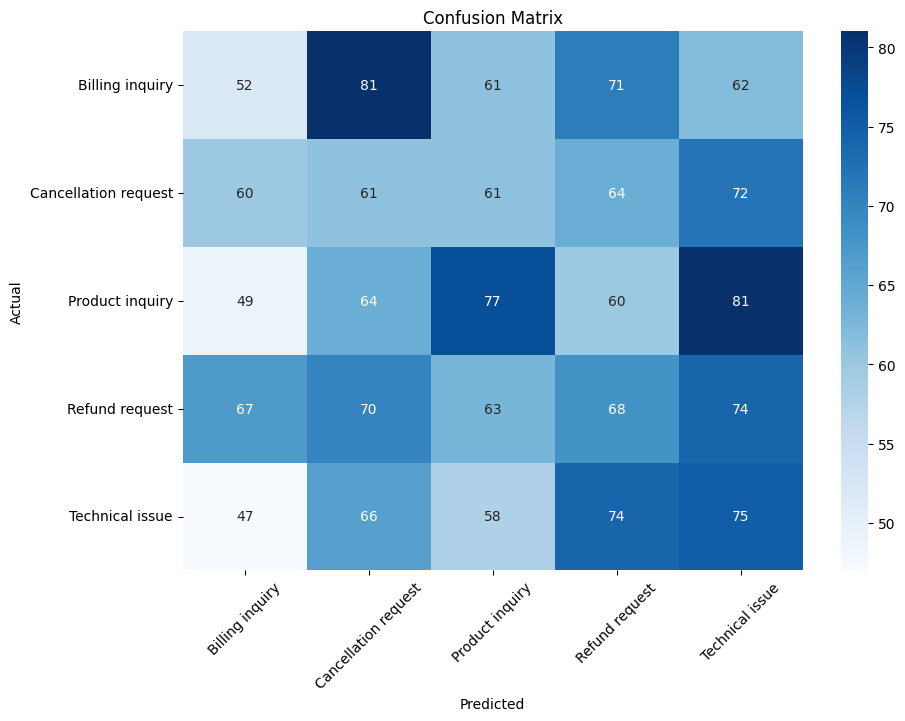

In [84]:
cm = confusion_matrix(y_test, y_pred)

labels = sorted(df['category'].unique())

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [77]:
sample_ticket = ["Unable to login into my account"]

sample_clean = [clean_text(text) for text in sample_ticket]

sample_vector = vectorizer.transform(sample_clean)

prediction = model.predict(sample_vector)

print("Predicted Category:", prediction[0])

Predicted Category: Product inquiry


In [78]:
priority = assign_priority(sample_ticket[0])

print("Priority Level:", priority)

Priority Level: Medium


In [79]:
def predict_ticket(ticket_text):
    
    cleaned = clean_text(ticket_text)
    
    vectorized = vectorizer.transform([cleaned])
    
    category = model.predict(vectorized)[0]
    
    priority = assign_priority(ticket_text)
    
    print("Ticket :", ticket_text)
    print("Predicted Category :", category)
    print("Priority :", priority)

In [80]:
predict_ticket("Payment failed but money deducted from bank")

Ticket : Payment failed but money deducted from bank
Predicted Category : Refund request
Priority : High


In [81]:
import pickle

pickle.dump(model, open("ticket_classifier.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

In [82]:
loaded_model = pickle.load(open("ticket_classifier.pkl", "rb"))
loaded_vectorizer = pickle.load(open("tfidf_vectorizer.pkl", "rb"))

In [83]:
new_ticket = "Server is down and application not working"

cleaned = clean_text(new_ticket)

vectorized = loaded_vectorizer.transform([cleaned])

prediction = loaded_model.predict(vectorized)

print("Category:", prediction[0])
print("Priority:", assign_priority(new_ticket))

Category: Billing inquiry
Priority: Low
